In [1]:
import os
import sys
import re
import random
import numpy as np
import json

sys.path.append("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/")

import matplotlib.pyplot as plt

# from utls.loading import load_results, load_results_with_exclusion_no_dropping, move_sequences_to_used, load_results_with_exclusion
# from utls.dprime import recompute_dprime_by_isi_per_subject
# from utls.reliability import compute_itemwise_split_half_reliability
# from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir, plot_power_curve, plot_groupwise_item_response_scatter

# from utls.reliability import compute_power_curve
# from utls.plotting import plot_power_curve


from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used,split_by_musicianship,load_results_with_exclusion_no_dropping,refresh_unused_batch, update_sequences_after_qc, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability, estimate_split_half_reliability, compute_itemwise_split_half_reliability_by_isi
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir, plot_groupwise_item_response_scatter, plot_power_curve_sem, plot_itemwise_hit_fa_relationship

from utls.reliability import compute_power_curve
from utls.plotting import plot_power_curve, plot_dprime_by_isi#, plot_groupwise_item_response_scatter
from scipy.stats import norm
from collections import defaultdict


from collections import Counter

import pandas as pd


from utls.analysis_helpers import rocs_across_noise, compute_scaling_vs_human
from utls.analysis_helpers import auroc_to_dprime, compute_model_dprime_curve
from utls.analysis_helpers import roc_for_isi, auroc_to_dprime
from utls.plotting import plot_across_noise, plot_noise_overlays
from utls.io_utils import make_model_save_dir, save_all_figures, save_single_figure, save_runs_summary
from utls.roc_utils import roc_from_arrays, plot_roc, roc_from_arrays_with_threshold
from utls.runners_utils import *



def _clip(p, eps=1e-2):
    return np.clip(p, eps, 1 - eps)

def compute_population_fa_rate(df):
    """
    df must contain per-subject aggregated rows with column 'fa_rate'.
    We compute the mean FA rate ACROSS subjects (not pooled).
    """
    return df["fa_rate"].mean()

def compute_population_hit_rates_by_isi(df):
    """
    df must contain columns: isi, hit_rate.
    We compute mean hit rate across subjects for each ISI.
    Returns Series indexed by ISI.
    """
    return df.groupby("isi")["hit_rate"].mean().sort_index()


def compute_dprime_from_rates(hit, fa):
    hit = _clip(hit)
    fa = _clip(fa)
    return norm.ppf(hit) - norm.ppf(fa)


def compute_dprime_curve(df):
    """
    df is your per-subject-per-isi summary df.
    """
    fa = compute_population_fa_rate(df)
    hit_rates = compute_population_hit_rates_by_isi(df)

    isis = hit_rates.index.to_numpy()
    dp = np.array([compute_dprime_from_rates(h, fa) for h in hit_rates.values])
    return isis, dp

# ============================================
# Bootstrapping
# ============================================

def bootstrap_dprime(df, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    subjects = df["subject"].unique()
    isis, _ = compute_dprime_curve(df)
    n_isi = len(isis)

    boot_mat = np.zeros((n_boot, n_isi))

    for b in range(n_boot):
        # sample subjects
        sampled = rng.choice(subjects, size=len(subjects), replace=True)

        # create bootstrapped df
        df_s = df[df["subject"].isin(sampled)]

        # recompute d'
        _, dp = compute_dprime_curve(df_s)
        boot_mat[b] = dp

    mean_dp = boot_mat.mean(axis=0)
    sem_dp = boot_mat.std(axis=0, ddof=1)
    ci_low = np.percentile(boot_mat, 2.5, axis=0)
    ci_high = np.percentile(boot_mat, 97.5, axis=0)

    return {
        "isis": isis,
        "mean": mean_dp,
        "sem": sem_dp,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "boot_matrix": boot_mat,
    }

def p_to_star(p):
    if p < 1e-4: return f"**** p={p:.3f}"
    if p < 1e-3: return f"*** p={p:.3f}"
    if p < 0.01: return f"** p={p:.3f}"
    if p < 0.05: return f"* p={p:.3f}"
    return f"n.s. p={p:.3f}"

def run_analysis(df, n_boot=5000):
    # Remove unwanted ISI
    df_removed = df[df["isi"] != -1].copy()
    isis, dp = compute_dprime_curve(df_removed)
    boot = bootstrap_dprime(df_removed, n_boot=n_boot)
    N = df_removed["subject"].nunique()

    hrs = compute_population_hit_rates_by_isi(df)
    print(hrs)
    fa  = compute_population_fa_rate(df)
    return {
        "isis": isis,
        "dprime": dp,
        "boot": boot,
        "hrs": hrs,
        "fa": fa,
        "N": N
    }

def compute_yes_rate_from_exps(exps):
    """
    Compute mean participant-level yes-rate.
    YES = response >= 1.
    """
    import pandas as pd
    person_rates = []

    for exp in exps:
        resp = pd.to_numeric(exp.response, errors="coerce")
        yes_rate = np.mean(resp >= 1)
        person_rates.append(yes_rate)

    return np.mean(person_rates)

def parse_seq_id(seq):
    """
    Extract integer sequence index from seq identifier.
    Supports int, '12', 'seq_12', 'sequence12.json', etc.
    """
    if isinstance(seq, int):
        return seq
    if isinstance(seq, str):
        nums = re.findall(r"\d+", seq)
        if not nums:
            raise ValueError(f"Could not parse seq id from {seq}")
        return int(nums[-1])
    raise TypeError(f"Unsupported seq type: {type(seq)}")


def assign_batches(seq_ids, batch_size, start_index=0):
    """
    Map seq_id -> batch_id using integer division.
    """
    return {
        seq_id: (seq_id - start_index) // batch_size
        for seq_id in seq_ids
    }


def filter_full_batches(exps, seqs, fnames, batch_size, start_index=0):
    """
    Keep only participants whose sequences belong to *complete* batches.
    """
    # ---- parse sequence indices ----
    seq_ids = np.array([parse_seq_id(s) for s in seqs])

    # ---- assign batches ----
    batch_ids = assign_batches(seq_ids, batch_size, start_index)

    batch_to_indices = defaultdict(list)
    for i, s in enumerate(seq_ids):
        batch_to_indices[batch_ids[s]].append(i)

    # ---- keep only full batches ----
    full_batches = {
        b for b, idxs in batch_to_indices.items()
        if len(idxs) == batch_size
    }

    keep_mask = np.array([
        batch_ids[s] in full_batches for s in seq_ids
    ])

    # ---- filter everything consistently ----
    exps_f  = [e for e, k in zip(exps, keep_mask) if k]
    seqs_f  = [s for s, k in zip(seqs, keep_mask) if k]
    fnames_f = [f for f, k in zip(fnames, keep_mask) if k]

    info = {
        "n_total_participants": len(seqs),
        "n_kept_participants": len(seqs_f),
        "n_full_batches": len(full_batches),
        "full_batches": sorted(full_batches),
    }

    return exps_f, seqs_f, fnames_f, info

def load_experiment_data(which_task, which_isi, is_multi, old=False, musicians=False):
    """
    Returns:
        experiment_list (list[list[str]])
        all_files       (list[str])
        name_to_idx     (dict)
        human_runs      (list)
    """

    batch_size = 8
    active_batch_size = batch_size*18
    if not is_multi:
        tasks = ["ind-nature-len120", "global-music-len120",
                 "atexts-len120", "nhs-region-len120"]
        base_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{{}}/sequences/isi_{which_isi}/len120/"
    else:
        tasks = ["env-sounds", "glob-music", "atexts", "nhs-region-len120"]
        base_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{}/sequences/len120_multi/"

    task_name = tasks[which_task]

    # map tasks → set names
    seqs_paths = {
        tasks[0]: "mem_exp_ind-nature_2025",
        tasks[1]: "global-music-2025-n_80",
        tasks[2]: "mem_exp_atexts_2025",
        tasks[3]: "nhs-region-n_80",
    }

    hr_task_names = { tasks[0]: "Industrial and Nature", 
                     tasks[1]: "Globalized Music",
                     tasks[2]: "Auditory Textures",
                     tasks[3]: " 'Natural History of Song' "}

    hr_task_name = hr_task_names[task_name]

    # load human data
    if not is_multi:
        if task_name == "glob-music":
            if musicians:
                exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
                    f"/mindhive/mcdermott/www/bjmedina/experiments/glob-music/results/glob-music/len120_musicians/",
                    min_dprime=2, min_trials=120, skip_len60=True,
                    verbose=False, return_skipped=True)
            else:
                exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
                    f"/mindhive/mcdermott/www/bjmedina/experiments/glob-music/results/glob-music/len120_nonmusicians",
                    min_dprime=2, min_trials=120, skip_len60=True,
                    verbose=False, return_skipped=True)
        else:
            exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
                f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/"
                f"isi_{which_isi}/{task_name}",
                min_dprime=2, min_trials=120, skip_len60=True,
                verbose=False, return_skipped=True)
    else:
        exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
            f"/mindhive/mcdermott/www/bjmedina/experiments/{task_name}/results/"
            f"{task_name}/len120_multi",
            min_dprime=2, min_trials=120, skip_len60=True,
            verbose=False, return_skipped=True)

    # ---- group indices by sequence ----
    seq_to_indices = defaultdict(list)
    for i, s in enumerate(seqs):
        seq_to_indices[s].append(i)
    
    # ---- randomly keep one index per sequence ----
    keep = [random.choice(idxs) for idxs in seq_to_indices.values()]
    
    # ---- apply filter ----
    exps   = [exps[i]   for i in keep]
    seqs   = [seqs[i]   for i in keep]
    fnames = [fnames[i] for i in keep]

    if not old:

        current_batch = refresh_unused_batch(base_path.format(seqs_paths[task_name]), 8)
        
        # ---- extract seq numbers ----
        seqnums = [int(re.search(r"seq(\d+)", s).group(1)) for s in seqs]
        
        # ---- group seqnums by batch ----
        batch_to_seqnums = defaultdict(set)
        for n in seqnums:
            batch_id = (n - 1) // batch_size
            batch_to_seqnums[batch_id].add(n)
        
        # ---- determine which batches are complete ----
        complete_batches = {
            b for b, nums in batch_to_seqnums.items()
            if nums == set(range(b * batch_size + 1, b * batch_size + batch_size + 1))
        }
        
        # ---- filter everything in lockstep ----
        keep = [
            i for i, n in enumerate(seqnums)
            if (n - 1) // batch_size in complete_batches
        ]
        
        exps   = [exps[i] for i in keep]
        seqs   = [seqs[i] for i in keep]
        fnames = [fnames[i] for i in keep]

    # load stimulus sequences
    experiment_list = []
    seq_dir = base_path.format(seqs_paths[task_name])
    stim_base = "/".join(seq_dir.split("/")[:-3])

    for seq in seqs:
        with open(seq_dir + seq, "r") as f:
            data = json.load(f)
        stim_files = [stim_base + "/" + s for s in data["filenames_order"]]
        experiment_list.append(stim_files)

    # collapse all unique files
    all_files = sorted({fn for seq in experiment_list for fn in seq})
    name_to_idx = {fn: i for i, fn in enumerate(all_files)}

    # convert human runs
    human_runs = [convert_human_to_model_struct(e) for e in exps]

    return experiment_list, all_files, name_to_idx, human_runs, task_name, hr_task_name, exps, seqs, fnames

In [ ]:
# # results = set(glob.glob("/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/ind-nature-len120/*csv"))
# # results = list(results)

which_isi=16
batch_size = 8
active_batch_size = batch_size*10
which_task = 0
musicians = True
is_multi=False

tasks = ["ind-nature-len120" ,"global-music-len120", "atexts-len120", "nhs-region-len120"]
if which_task == 1:
    if musicians:
        base_path = f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{{}}/sequences/isi_{which_isi}/len120_musicians/"
    else:
        base_path = f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{{}}/sequences/isi_{which_isi}/len120_nonmusicians/"
else:
    base_path = f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{{}}/sequences/isi_{which_isi}/len120/"
seqs_paths = {"ind-nature-len120": "mem_exp_ind-nature_2025", 
              "global-music-len120": "global-music-2025-n_80",
              "atexts-len120": "mem_exp_atexts_2025",
              "nhs-region-len120": "nhs-region-n_80"}


hr_task_name = {"ind-nature-len120": "Industrial and Nature", 
              "global-music-len120": "Globalized Music",
              "atexts-len120": "Auditory Textures",
              "nhs-region-len120": " 'Natural History of Song' "}


if which_task == 1:
    base_path = "/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{}/sequences/len120_multi/"

task_name = tasks[which_task]

task_hr_name = hr_task_name[tasks[which_task]]

safe_name = task_hr_name.lower().replace(" ", "_")  # e.g., "globalized_music"
save_dir = os.path.join("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/figures/human-results/single-isi", safe_name)

ensure_dir(save_dir)

hr_task_names = { tasks[0]: "Industrial and Nature", 
                 tasks[1]: "Globalized Music",
                 tasks[2]: "Auditory Textures",
                 tasks[3]: " 'Natural History of Song' "}

hr_task_name = task_hr_name

# load human data
if not is_multi:
    if which_task == 1:
        if musicians:
            exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
                f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/bjmedina/experiments/glob-music/results/glob-music/len120_musicians/",
                min_dprime=2, min_trials=120, skip_len60=True,
                verbose=False, return_skipped=True)
        else:
            exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
                f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/bjmedina/experiments/glob-music/results/glob-music/len120_nonmusicians",
                min_dprime=2, min_trials=120, skip_len60=True,
                verbose=False, return_skipped=True)
    else:
        exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
            f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/"
            f"isi_{which_isi}/{task_name}",
            min_dprime=2, min_trials=120, skip_len60=True,
            verbose=False, return_skipped=True)
else:
    exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
        f"/orcd/data/jhm/001/om2/bjmedina/mindhive/mcdermott/www/bjmedina/experiments/{task_name}/results/"
        f"{task_name}/len120_multi",
        min_dprime=2, min_trials=120, skip_len60=True,
        verbose=False, return_skipped=True)

# ---- group indices by sequence ----
seq_to_indices = defaultdict(list)
for i, s in enumerate(seqs):
    seq_to_indices[s].append(i)

# ---- randomly keep one index per sequence ----
keep = [random.choice(idxs) for idxs in seq_to_indices.values()]

# ---- apply filter ----
exps   = [exps[i]   for i in keep]
seqs   = [seqs[i]   for i in keep]
fnames = [fnames[i] for i in keep]

# print(base_path.format(seqs_paths[tasks[which_task]]))

# move_sequences_to_used(base_path.format(seqs_paths[tasks[which_task]]), seqs)

# good = set(seqs)
# skipped_seqs = [s for s in skipped_seqs if s not in good]

# seqs_good = seqs          # Passed d' threshold
# seqs_bad  = skipped_seqs  # Failed d' threshold


# info = update_sequences_after_qc(
#     seq_dir=base_path.format(seqs_paths[tasks[which_task]]),
#     seqs_good=seqs_good,
#     seqs_bad=seqs_bad
# )
# print(base_path.format(seqs_paths[tasks[which_task]]))
# current_batch = refresh_unused_batch(base_path.format(seqs_paths[tasks[which_task]]), active_batch_size)

# print("Number of participants used in analysis:", len(exps))
# print("New active batch:", current_batch, "of size ", len(current_batch))


# safe_name = which_task.lower().replace(" ", "_")  # e.g., "globalized_music"
# save_dir = os.path.join("/orcd/data/jhm/001/om2/bjmedina/om2/user/bjmedina/auditory-memory/memory/figures/human-results/single-isi", safe_name)

# ensure_dir(save_dir)

# # ---- extract seq numbers ----
# seqnums = [int(re.search(r"seq(\d+)", s).group(1)) for s in seqs]

# # ---- group seqnums by batch ----
# batch_to_seqnums = defaultdict(set)
# for n in seqnums:
#     batch_id = (n - 1) // batch_size
#     batch_to_seqnums[batch_id].add(n)

# # ---- determine which batches are complete ----
# complete_batches = {
#     b for b, nums in batch_to_seqnums.items()
#     if nums == set(range(b * batch_size + 1, b * batch_size + batch_size + 1))
# }

# # ---- filter everything in lockstep ----
# keep = [
#     i for i, n in enumerate(seqnums)
#     if (n - 1) // batch_size in complete_batches
# ]

# exps   = [exps[i] for i in keep]
# seqs   = [seqs[i] for i in keep]
# fnames = [fnames[i] for i in keep]

# print("Kept batches:", sorted(complete_batches))
# print("N kept:", len(seqs))

# experienced, beginner = split_by_musicianship(exps)
# print(len(experienced), len(beginner))

Directory already exists: /orcd/data/jhm/001/om2/bjmedina/om2/user/bjmedina/auditory-memory/memory/figures/human-results/single-isi/industrial_and_nature


In [4]:
human_curve_multi = compute_human_curve(human_runs, True, None)
print(human_curve_multi)

NameError: name 'human_runs' is not defined

In [19]:
x = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, which_isi]
x_filtered = x[x['isi'].isin(valid_isi_values)].copy()
x = x_filtered

out = run_analysis(x)
yes_rate = compute_yes_rate_from_exps(exps)
out["yes_rate"] = yes_rate
print(out['hrs'].loc[16])
print(tasks[which_task])

isi
-1          NaN
 0     0.992000
 16    0.859556
Name: hit_rate, dtype: float64
0.8595555555555556
ind-nature-len120


In [20]:
# Only consider repeat trials with ISI >= 16
results_long = compute_itemwise_split_half_reliability(exps, min_isi=which_isi, max_isi=which_isi)
hits = results_long['itemwise_responses']['hits']
false_alarms  = results_long['itemwise_responses']['false_alarms']

# Optional coloring
label_hits_fa = {item: 'hit' for item in hits.columns}
label_hits_fa.update({item: 'fa' for item in false_alarms.columns})

print(results_long['split_half_reliability'])
print(f"[DEBUG] Final signal df shape: {hits.shape}")
print(f"[DEBUG] Final noise df shape: {false_alarms.shape}")
print(f"[DEBUG] Columns (signal items): {hits.columns[:5].tolist()}...")
print(f"[DEBUG] Columns (noise items): {false_alarms.columns[:5].tolist()}...")

{'hits': (0.4582097842051023, 0.07403771202381632), 'false_alarms': (0.795125419987217, 0.031975395583056086)}
[DEBUG] Final signal df shape: (75, 80)
[DEBUG] Final noise df shape: (75, 80)
[DEBUG] Columns (signal items): ['mem_stim_0.wav', 'mem_stim_1.wav', 'mem_stim_10.wav', 'mem_stim_11.wav', 'mem_stim_12.wav']...
[DEBUG] Columns (noise items): ['mem_stim_0.wav', 'mem_stim_1.wav', 'mem_stim_10.wav', 'mem_stim_11.wav', 'mem_stim_12.wav']...


In [21]:
#results_long

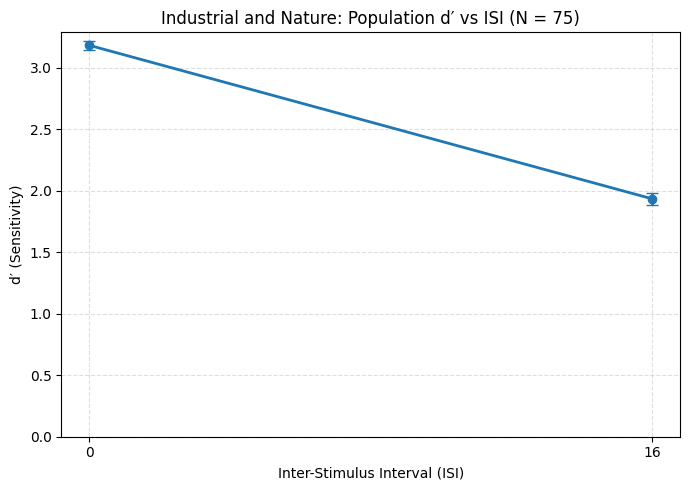

In [22]:
isis = out["isis"]
dprime = out["dprime"]
boot = out["boot"]

plt.figure(figsize=(7,5))
plt.errorbar(
    isis,
    dprime,
    yerr=boot["sem"],
    fmt='o-',
    capsize=4,
    linewidth=2,
    markersize=6
)



isi_plot_dir = os.path.join(save_dir, "dprime-vs-isi.png")

plt.xticks(isis, isis)
plt.ylim(bottom=0)
plt.xlabel("Inter-Stimulus Interval (ISI)")
plt.ylabel("d′ (Sensitivity)")
plt.title(f"{task_hr_name}: Population d′ vs ISI (N = {out['N']})")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(isi_plot_dir)
plt.show()

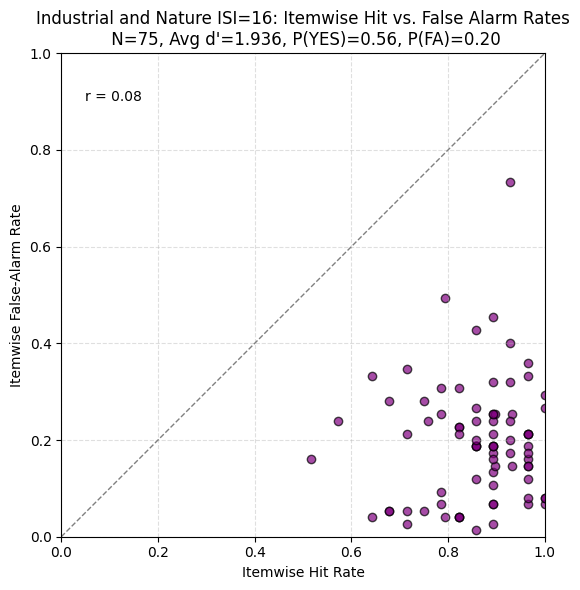

In [9]:
hr_far_cons_plot_dir = os.path.join(save_dir, "hr-fa-rate-consistency.png")
plot_itemwise_hit_fa_relationship(results_long, title=f"{task_hr_name} ISI={which_isi}: Itemwise Hit vs. False Alarm Rates\n N={out["N"]}, Avg d'={dprime[1]:.3f}, P(YES)={out["yes_rate"]:.2f}, P(FA)={out['fa']:.2f}")#, save_path=hr_far_cons_plot_dir)
plot_itemwise_hit_fa_relationship(results_long, title=f"{task_hr_name} ISI={which_isi}: Itemwise Hit vs. False Alarm Rates\n N={out["N"]}, Avg d'={dprime[1]:.3f}, P(YES)={out["yes_rate"]:.2f}, P(FA)={out['fa']:.2f}", save_path=hr_far_cons_plot_dir)

In [10]:
hr_cons_plot_dir = os.path.join(save_dir, "hit-rate-consistency.png")
far_cons_plot_dir = os.path.join(save_dir, "false-alarm-rate-consistency.png")

# Split groups (rows are participants)
plot_groupwise_item_response_scatter(results_long, kind="hits",title=f"{task_hr_name} ISI={which_isi}: Itemwise Hit Rates\n N={out["N"]}, Avg d'={dprime[1]:.3f}, P(YES)={out["yes_rate"]:.2f}, P(FA)={out['fa']:.2f}", save_path=hr_cons_plot_dir)
plot_groupwise_item_response_scatter(results_long, kind="false_alarms", save_path=far_cons_plot_dir, title=f"{task_hr_name} ISI={which_isi}: Itemwise False Alarm Rates\n N={out["N"]}, Avg d'={dprime[1]:.3f}, P(YES)={out["yes_rate"]:.2f}, P(FA)={out['fa']:.2f}")

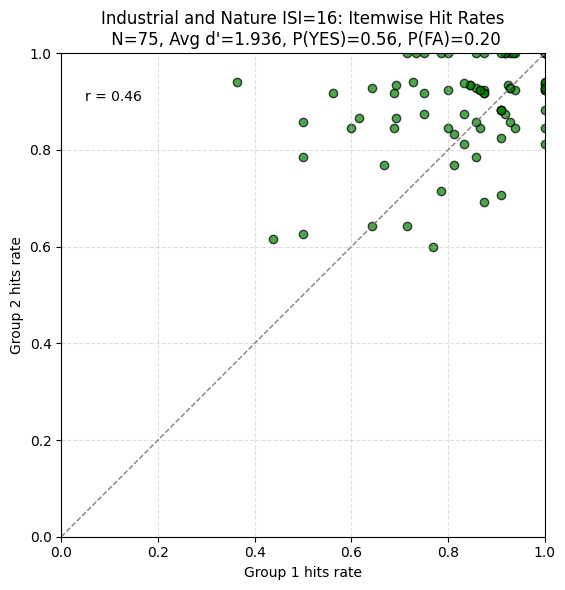

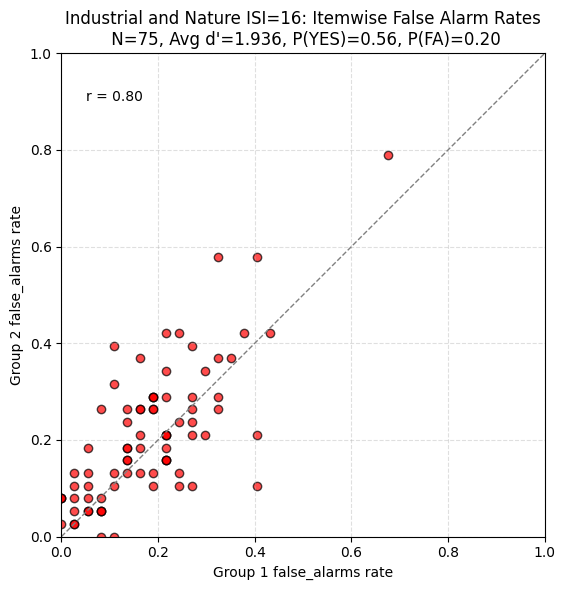

In [11]:
plot_groupwise_item_response_scatter(results_long, kind="hits", title=f"{task_hr_name} ISI={which_isi}: Itemwise Hit Rates\n N={out["N"]}, Avg d'={dprime[1]:.3f}, P(YES)={out["yes_rate"]:.2f}, P(FA)={out['fa']:.2f}")#, save_path=hr_cons_plot_dir)
plot_groupwise_item_response_scatter(results_long, kind="false_alarms", title=f"{task_hr_name} ISI={which_isi}: Itemwise False Alarm Rates\n N={out["N"]}, Avg d'={dprime[1]:.3f}, P(YES)={out["yes_rate"]:.2f}, P(FA)={out['fa']:.2f}")#, save_path=far_cons_plot_dir)

In [43]:
seed = 0

In [24]:
sizes, means, stds = compute_power_curve(
    exps,
    n_repeats=50,
    n_splits=100,
    max_participants=None,
    step=10,
    seed=seed,
    min_isi=which_isi,
    max_isi=which_isi,
    kind="hits",
    criterion=1
)


seed += 1

/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:193: RuntimeWarning: Mean of empty slice
  y = np.nanmean(group2.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:193: RuntimeWarning: Mean of empty slice
  y = np.nanmean(group2.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:193: RuntimeWarning: Mean of empty slice
  y = np.nanmean(group2.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)

[10, 20, 30, 40] [0.0822006742832832, 0.1824236245897058, 0.2612754414401397, 0.33576981039435005] [0.0898218215872678, 0.07252012031689069, 0.04777947198499066, 0.007372424741239031]


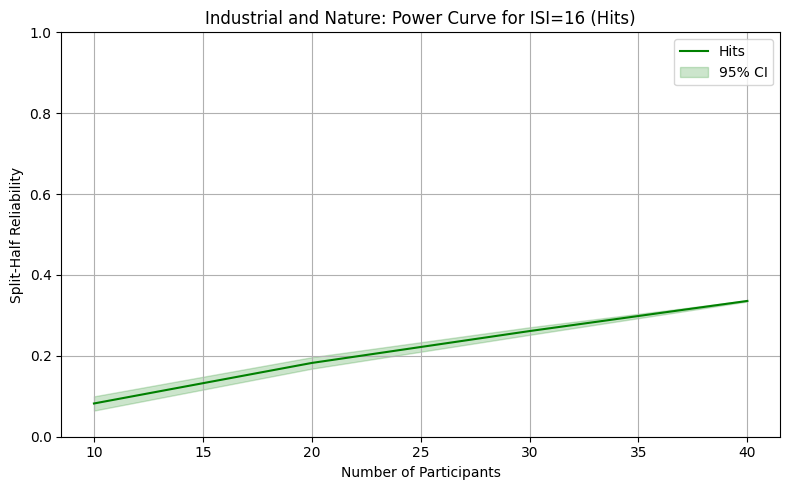

In [25]:
print(sizes, means, stds)
hit_pa_plot_dir = os.path.join(save_dir, f"hit-rate-power-analysis_isi{which_isi}.png")

plot_power_curve(sizes, means,
                 stds, kind="hits", title=f"{hr_task_name[which_task]}: Power Curve for ISI={which_isi} (Hits)", save_path=hit_pa_plot_dir)

In [26]:
sizes, means, stds = compute_power_curve(
    exps,
    n_repeats=50,
    n_splits=100,
    max_participants=None,
    step=10,
    seed=4282,
    min_isi=which_isi,
    max_isi=which_isi,
    kind="false_alarms",
    criterion=1
)

/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:193: RuntimeWarning: Mean of empty slice
  y = np.nanmean(group2.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:193: RuntimeWarning: Mean of empty slice
  y = np.nanmean(group2.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:193: RuntimeWarning: Mean of empty slice
  y = np.nanmean(group2.values, axis=0)
/om2/user/bjmedina/auditory-memory/memory/utls/reliability.py:192: RuntimeWarning: Mean of empty slice
  x = np.nanmean(group1.values, axis=0)

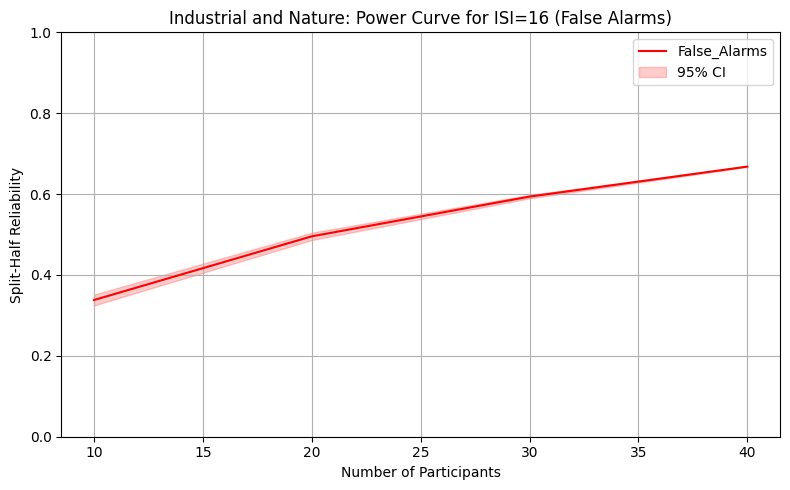

In [27]:
far_pa_plot_dir = os.path.join(save_dir, f"false-alarm-rate-power-analysis_isi{which_isi}.png")
plot_power_curve(sizes, means, stds, kind="false_alarms", title=f"{hr_task_name[which_task]}: Power Curve for ISI={which_isi} (False Alarms)", save_path=far_pa_plot_dir)

In [44]:
hits

,mem_stim_0.wav,mem_stim_1.wav,mem_stim_10.wav,mem_stim_11.wav,mem_stim_12.wav,mem_stim_13.wav,mem_stim_14.wav,mem_stim_15.wav,mem_stim_16.wav,mem_stim_17.wav,...,mem_stim_72.wav,mem_stim_73.wav,mem_stim_74.wav,mem_stim_75.wav,mem_stim_76.wav,mem_stim_77.wav,mem_stim_78.wav,mem_stim_79.wav,mem_stim_8.wav,mem_stim_9.wav
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,NaN
72,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
73,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
